<a href="https://colab.research.google.com/github/kunasing/m148-final-project/blob/main/Week3Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### 1) Explain what data set your team had chosen for the project.
We chose the Spotify Dataset.
#### 2) Explain the main features in the data that you are studying and why.
The features of the data include many spotify-created metrics such as danceability, acousticness, speechiness, instrumentalness, and liveness. It also contains information about the key, tempo, and time-signature. It also has data about the song’s popularity corresponding to how much the song has been played on Spotify. The feature we are most interested in is the genre, and we want to attempt to predict the genre based on the other data features.
#### 3) Include code that demonstrates some of the data cleaning your group has attempted. Some examples include handling missingness and imputation.
We checked for missing and duplicate data and removed it, we also genereated a clean csv that we will use for further analysis.

We also used the describe function to check the ranges for the data, since the numeric values have an expected range and all the values fall within that, we shouldn't have to worry about imputation.





In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math


In [ ]:
df = pd.read_csv("dataset.csv", index_col = 0)
df.sample(20)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
83179,18YRKiIZO4qDEc5Ik0Cry6,Marshmello;Anne-Marie;R3HAB,FRIENDS (R3hab Remix),FRIENDS - R3hab Remix,56,157142,True,0.545,0.814,9,-4.398,0,0.0409,0.028000,0.000000,0.0969,0.696,104.930,4,progressive-house
20655,0RwQG3x5q1HE0CDetUuYFk,Wiz Khalifa;PARTYNEXTDOOR,Midnight Music,Late Night Messages,1,282740,True,0.790,0.616,10,-7.397,0,0.0983,0.086500,0.000023,0.2200,0.312,92.967,4,dance
87360,2Pe2uda2pqu1CyK3RqtOAW,Lianne La Havas,20's R'n'B,Bittersweet,0,236640,False,0.570,0.409,5,-7.555,0,0.0331,0.345000,0.000188,0.2190,0.304,137.800,4,r-n-b
44846,7GAFuH9KR356f8ZW9ikL5Z,The Smashing Pumpkins,Aeroplane Flies High (Deluxe Edition),Mouths Of Babes,27,226333,False,0.328,0.833,0,-8.245,0,0.0349,0.000002,0.935000,0.3370,0.447,90.965,4,grunge
63372,2vk8PCaUuAZ63dsi1lqkn0,Big Star,#1 Record (Remastered),Thirteen,54,154480,False,0.456,0.344,0,-10.296,0,0.0298,0.565000,0.000009,0.1140,0.359,117.116,4,j-rock
99521,15OCqNPYoLziEAsbVnqRj5,Mimi Webb,Good Without,Good Without,69,182121,False,0.616,0.576,11,-5.495,0,0.0532,0.072300,0.000000,0.3750,0.269,89.962,4,singer-songwriter
12537,7izpDsmH5Hpxrx4s5OXITu,Alfred Hui,TVB無線電視劇情歌集,"護航 - (劇集 ""西遊記"" 片尾曲)",21,213237,False,0.521,0.580,9,-7.567,1,0.0490,0.626000,0.000000,0.0917,0.344,139.826,4,cantopop
110354,3SYO8wU4bEgIYt7AeGRIwG,Jody Wisternoff;James Grant,Nightwhisper,Nightwhisper,51,217000,False,0.674,0.894,1,-6.386,1,0.0341,0.001300,0.915000,0.1650,0.141,119.962,4,trance
58099,23bUtNc4PUyHNrYNolzMPq,White Zombie,Spooky Scary Season,"I'm Your Boogieman - From ""The Crow: City Of A...",0,267573,False,0.645,0.985,1,-3.715,1,0.1110,0.001130,0.010200,0.2230,0.446,113.934,4,industrial
102447,0YFPw3rQR1nSeyd3q0uY5h,Sturgill Simpson,Just Best Covers,In Bloom,0,240640,False,0.433,0.366,2,-8.980,0,0.0311,0.068200,0.248000,0.1230,0.267,78.366,4,songwriter


In [ ]:
df.shape

(114000, 20)

Check for NA

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [ ]:
rows_with_missing = df.isnull().any(axis=1)
df[rows_with_missing]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [ ]:
# Remove the only observation with missing value
df = df.drop(index=65900)

In [ ]:
duplicates = df.duplicated()
print(duplicates.sum())
df = df.drop_duplicates(subset=None, keep='first', inplace=False)

450


In [ ]:
df.select_dtypes('number').describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113549.000000,1.135490e+05,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,33.324433,2.280814e+05,0.567031,0.642091,5.309452,-8.243408,0.637866,0.084674,0.314064,0.155703,0.213613,0.474205,122.175745,3.904218
std,22.283855,1.064131e+05,0.173409,0.251053,3.560147,5.011422,0.480620,0.105762,0.331906,0.309217,0.190462,0.259204,29.972954,0.432117
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741840e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296000,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615880e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048700,0.273000,0.683000,140.074000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


#### 4) Include code that at least one exploratory data analysis (EDA) technique you have applied to your data and why. An example EDA could be one to help determine predictors for a response variable for simple linear regression


In [ ]:
df.select_dtypes('number').corr().round(2)

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.00,-0.01,0.04,0.00,-0.00,0.05,-0.01,-0.04,-0.03,-0.10,-0.01,-0.04,0.01,0.03
duration_ms,-0.01,1.00,-0.07,0.06,0.01,-0.00,-0.04,-0.06,-0.10,0.12,0.01,-0.15,0.02,0.02
danceability,0.04,-0.07,1.00,0.13,0.04,0.26,-0.07,0.11,-0.17,-0.19,-0.13,0.48,-0.05,0.21
energy,0.00,0.06,0.13,1.00,0.05,0.76,-0.08,0.14,-0.73,-0.18,0.18,0.26,0.25,0.19
key,-0.00,0.01,0.04,0.05,1.00,0.04,-0.14,0.02,-0.04,-0.01,-0.00,0.03,0.01,0.02
loudness,0.05,-0.00,0.26,0.76,0.04,1.00,-0.04,0.06,-0.59,-0.43,0.08,0.28,0.21,0.19
mode,-0.01,-0.04,-0.07,-0.08,-0.14,-0.04,1.00,-0.05,0.10,-0.05,0.01,0.02,0.00,-0.02
speechiness,-0.04,-0.06,0.11,0.14,0.02,0.06,-0.05,1.00,-0.00,-0.09,0.21,0.04,0.02,-0.00
acousticness,-0.03,-0.10,-0.17,-0.73,-0.04,-0.59,0.10,-0.00,1.00,0.10,-0.02,-0.11,-0.21,-0.18
instrumentalness,-0.10,0.12,-0.19,-0.18,-0.01,-0.43,-0.05,-0.09,0.10,1.00,-0.08,-0.32,-0.05,-0.08


In [ ]:
df.to_csv('cleaned1.csv', index=False)

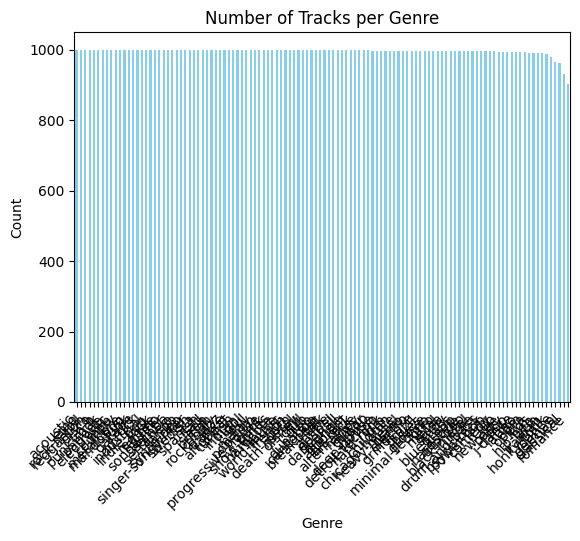

In [ ]:
genre_counts = df['track_genre'].value_counts()
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Tracks per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

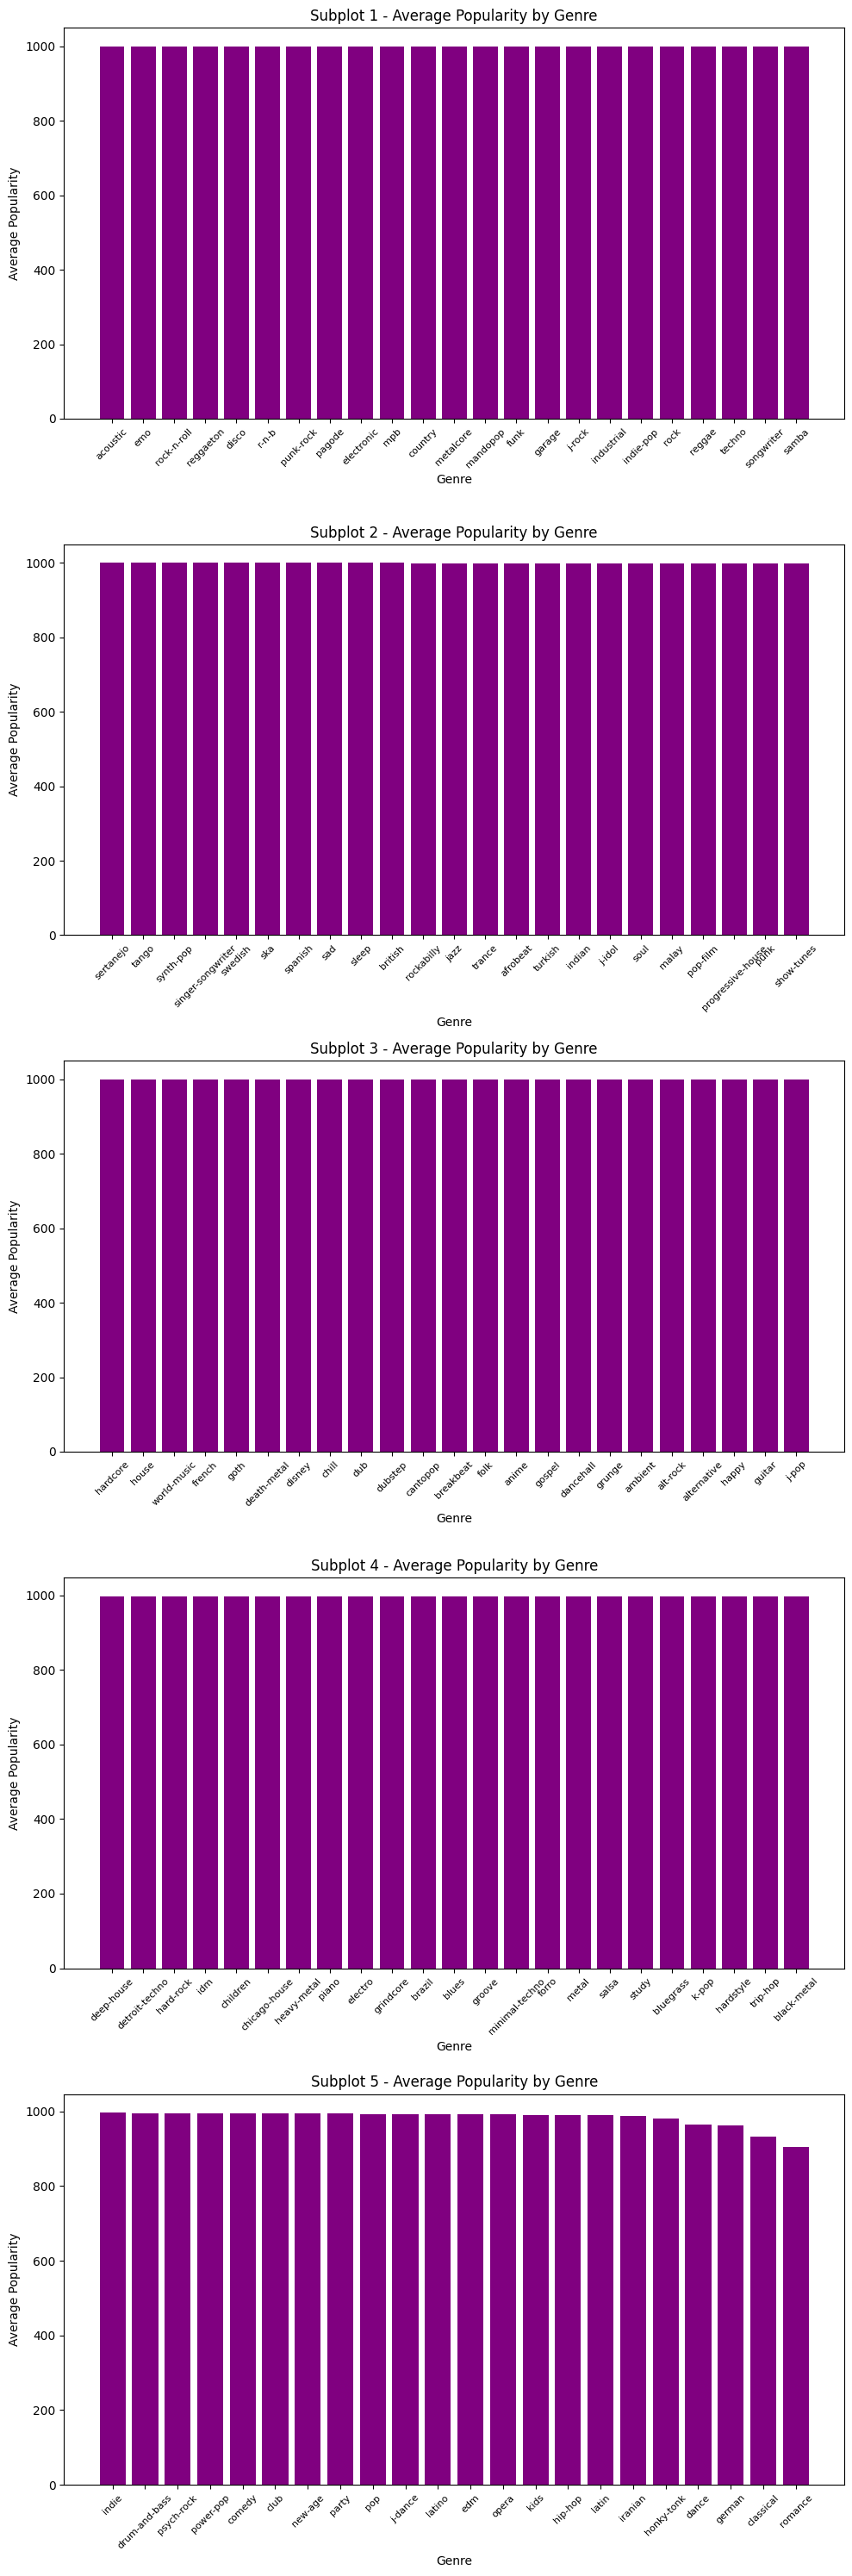

In [ ]:
num_splits = 5
num_items_per_plot = math.ceil(len(genre_counts) / num_splits)

# Create subplots
fig, axes = plt.subplots(nrows=num_splits, figsize=(10, 6 * num_splits))

# Flatten axes to easily iterate over them
axes = axes.flatten()

# Loop through splits and plot each subset in a different subplot
for i in range(num_splits):
    start_idx = i * num_items_per_plot
    end_idx = (i + 1) * num_items_per_plot

    # Subset the data for the current plot
    subset = genre_counts[start_idx:end_idx]

    # Plot each subset
    axes[i].bar(subset.index, subset.values, color='purple')
    axes[i].set_title(f'Subplot {i + 1} - Average Popularity by Genre')
    axes[i].set_ylabel('Average Popularity')
    axes[i].set_xlabel('Genre')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

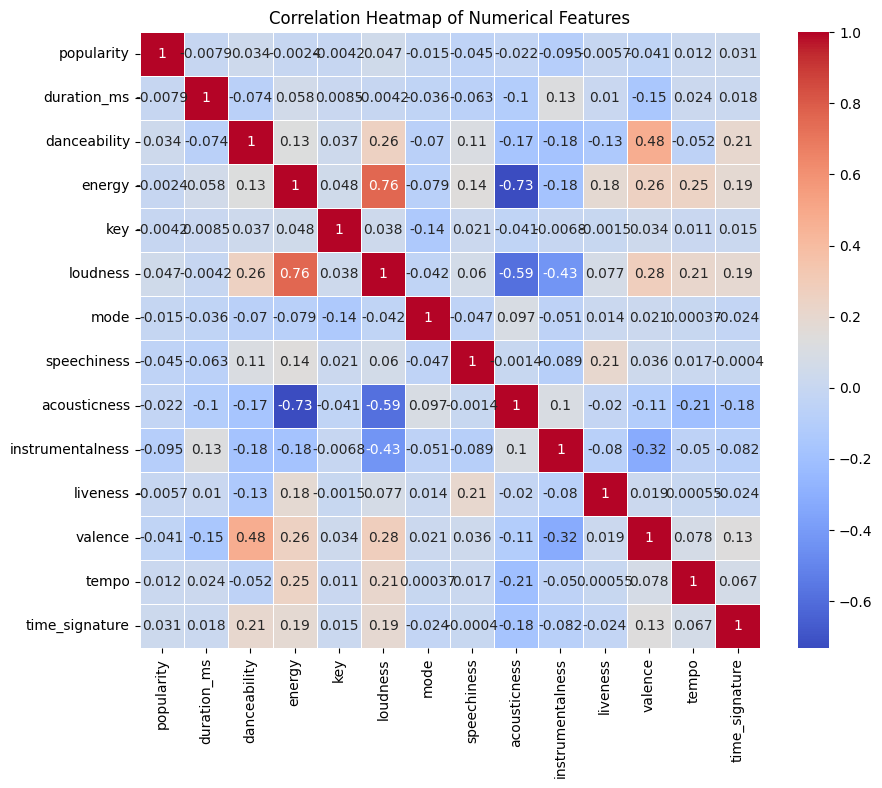

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

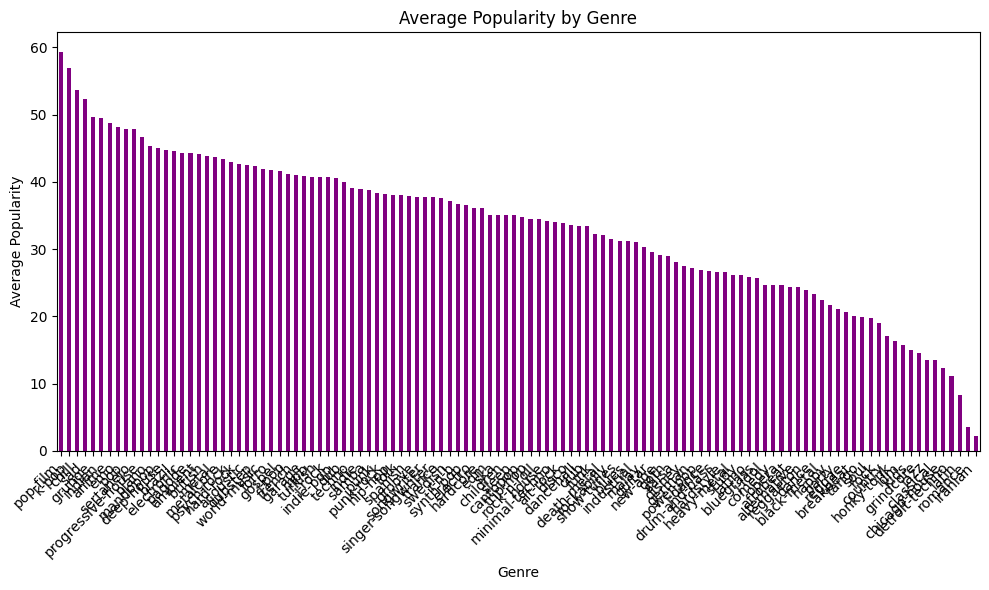

In [ ]:
avg_popularity_by_genre = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
avg_popularity_by_genre.plot(kind='bar', color='purple', figsize=(10, 6))
plt.title('Average Popularity by Genre')
plt.ylabel('Average Popularity')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


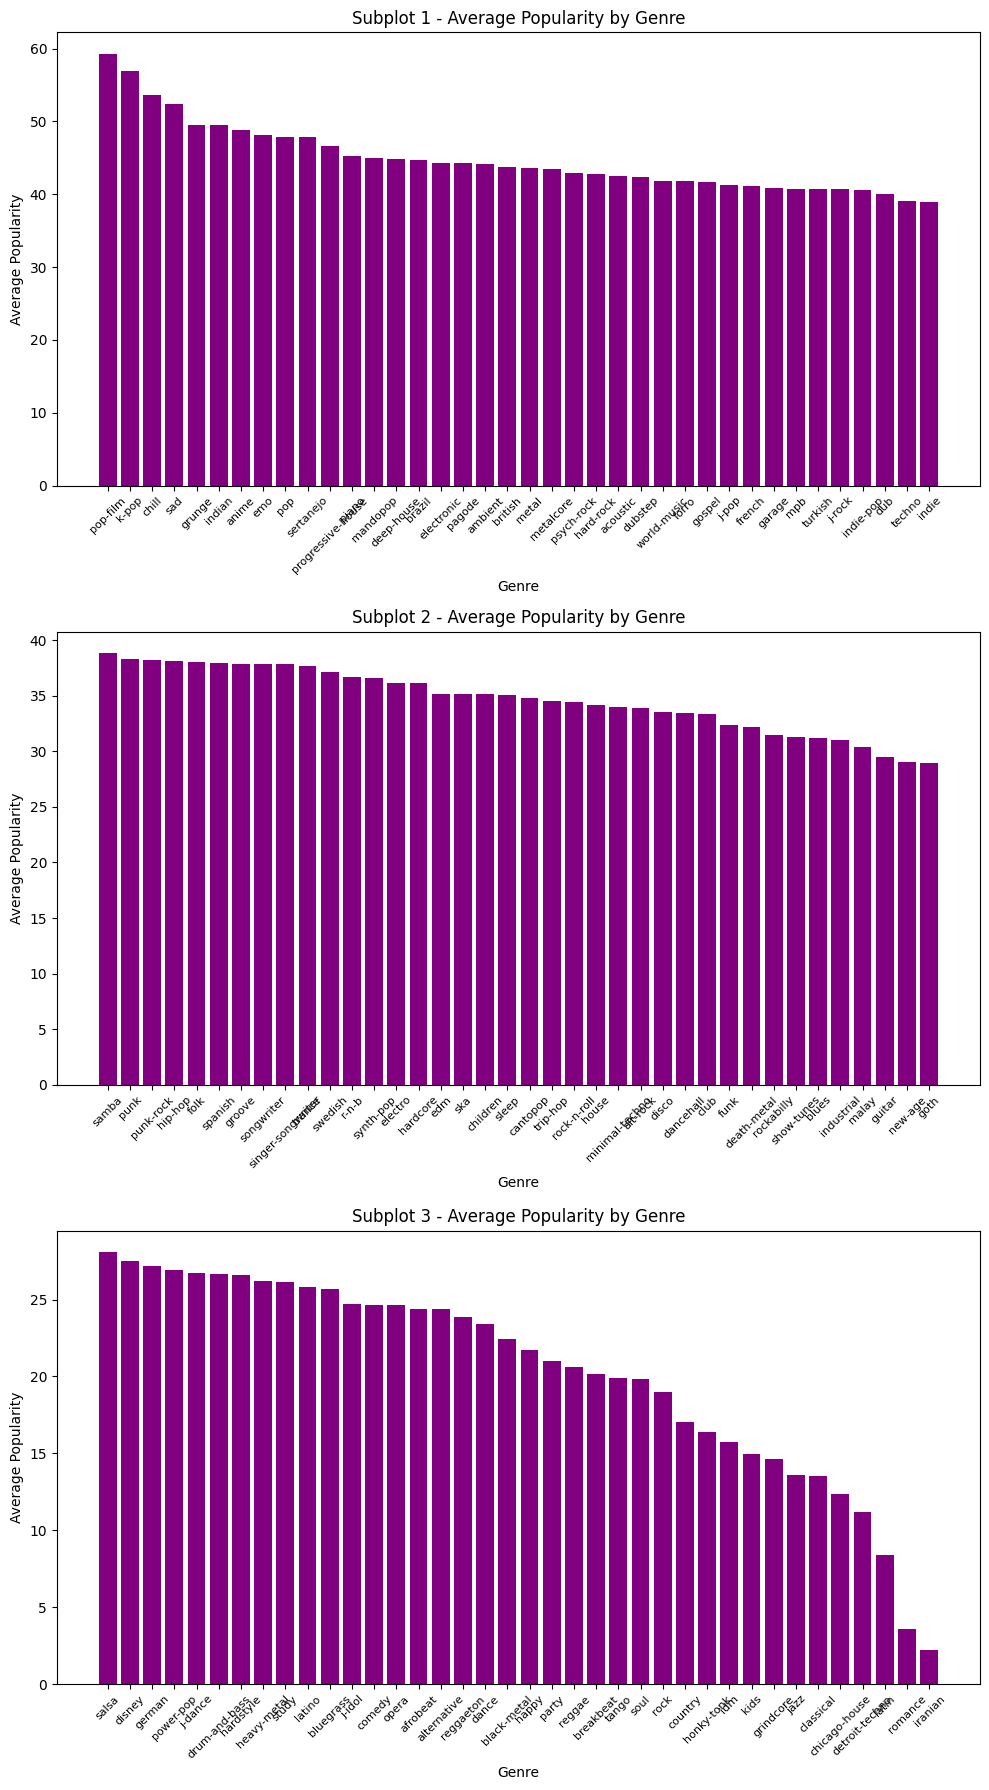

In [ ]:
num_splits = 3
num_items_per_plot = math.ceil(len(avg_popularity_by_genre) / num_splits)

# Create subplots
fig, axes = plt.subplots(nrows=num_splits, figsize=(10, 6 * num_splits))

# Flatten axes to easily iterate over them
axes = axes.flatten()

# Loop through splits and plot each subset in a different subplot
for i in range(num_splits):
    start_idx = i * num_items_per_plot
    end_idx = (i + 1) * num_items_per_plot

    # Subset the data for the current plot
    subset = avg_popularity_by_genre[start_idx:end_idx]

    # Plot each subset
    axes[i].bar(subset.index, subset.values, color='purple')
    axes[i].set_title(f'Subplot {i + 1} - Average Popularity by Genre')
    axes[i].set_ylabel('Average Popularity')
    axes[i].set_xlabel('Genre')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

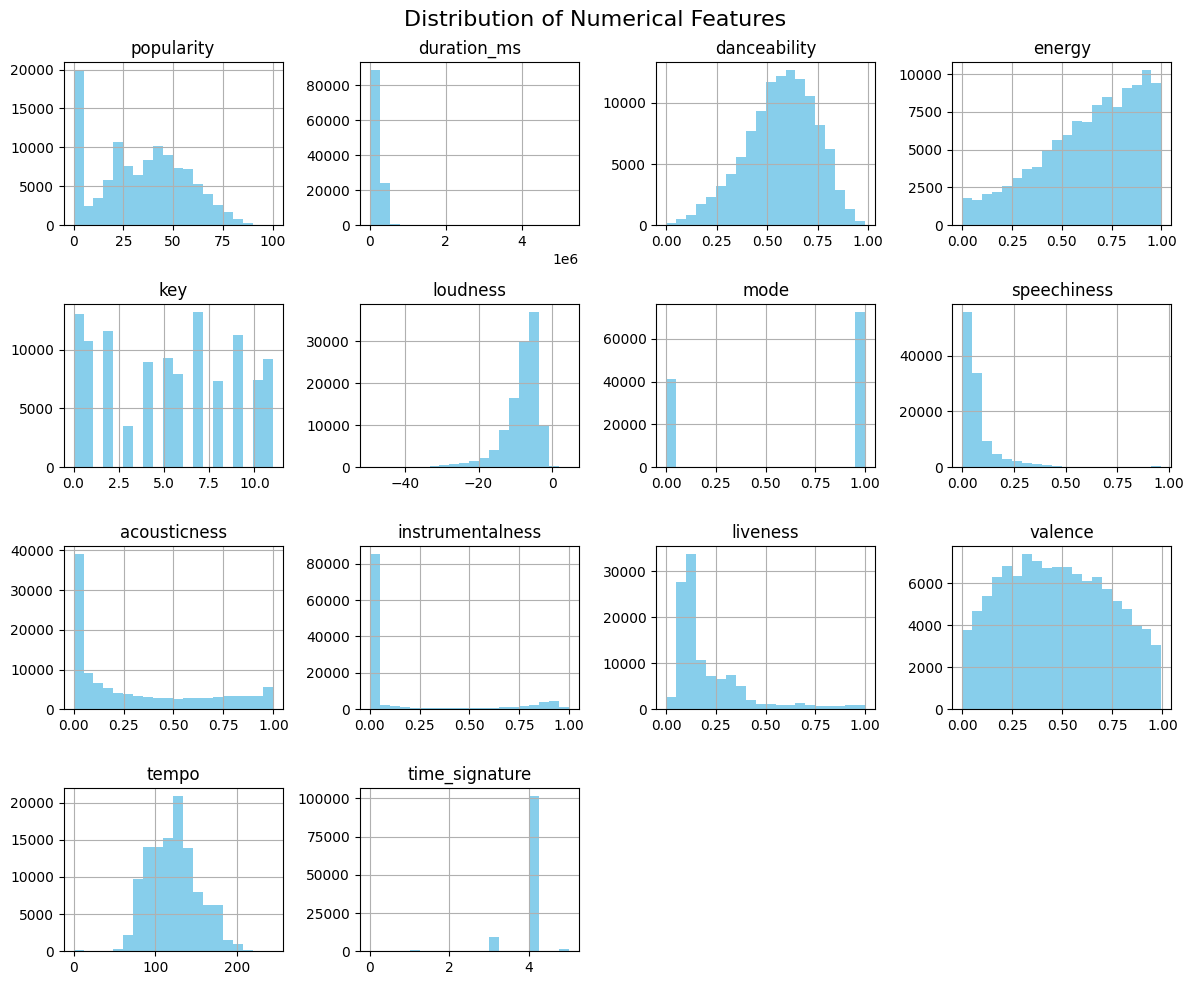

In [ ]:
numerical_cols = df.select_dtypes(include='number').columns

df[numerical_cols].hist(bins=20, figsize=(12, 10), color='skyblue')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


## Regression Model

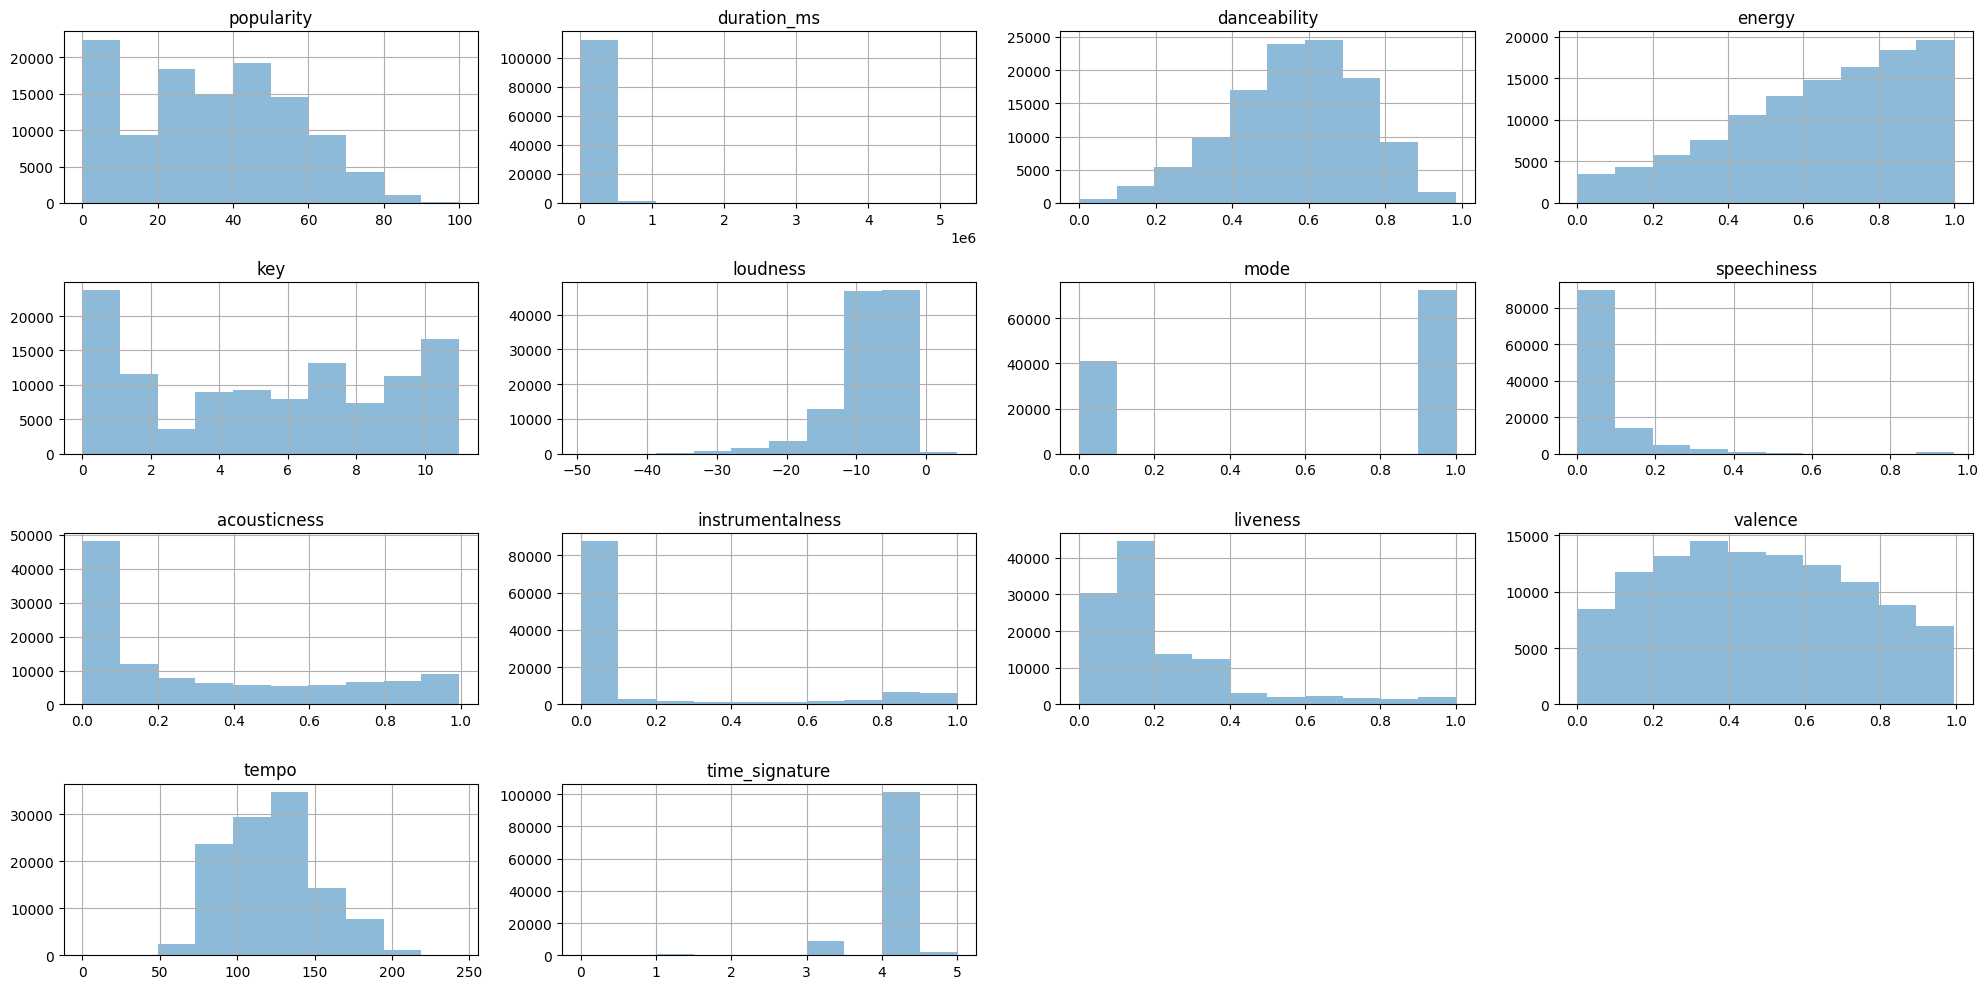

In [ ]:
df.hist(alpha=0.5, figsize=(20, 10))
plt.tight_layout()
plt.show()

In [ ]:
df.head(3)
import numpy as np

In [ ]:
columns_to_transform = ['popularity', 'danceability', 'energy', 'key', 'loudness',
                        'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                        'valence', 'tempo', 'time_signature']
df[columns_to_transform] = df[columns_to_transform].apply(lambda x: np.log(x + 1))

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


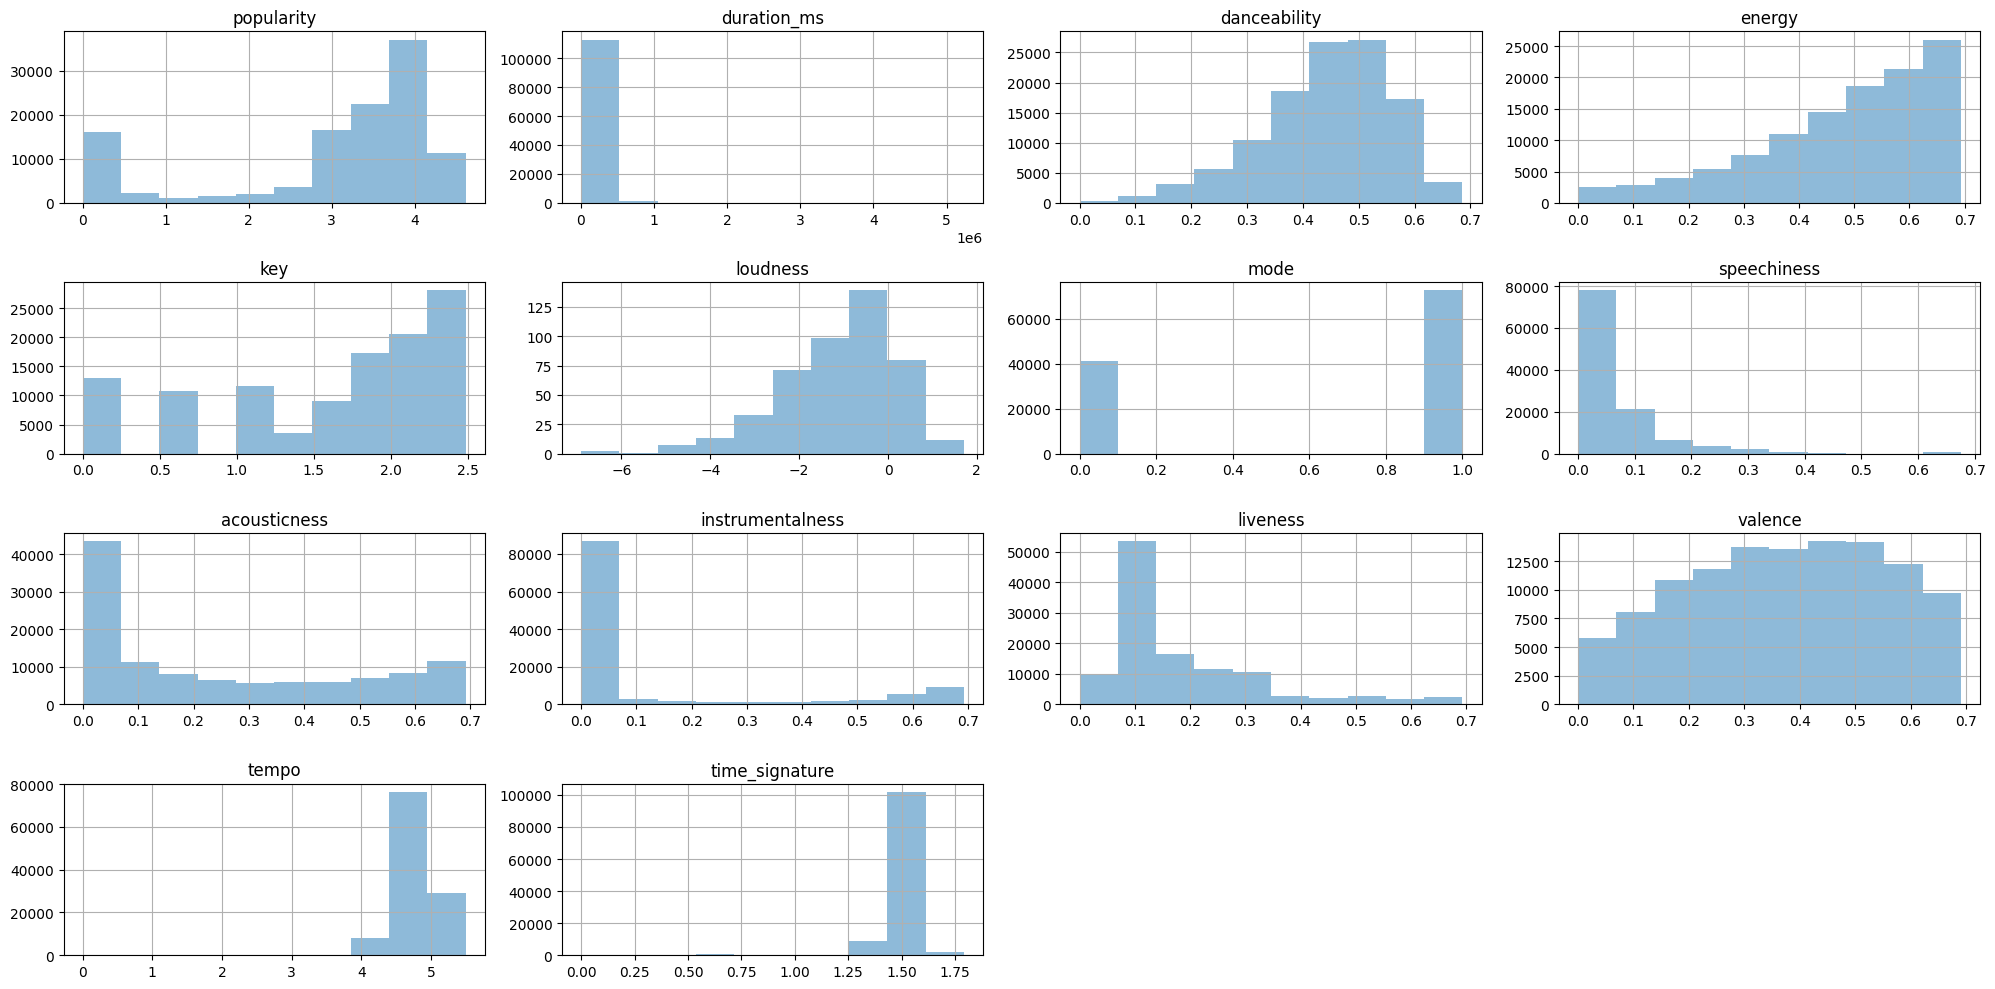

In [ ]:
df.hist(alpha=0.5, figsize=(20, 10))
plt.tight_layout()
plt.show()

In [ ]:
predictor_variables = ['popularity', 'danceability', 'energy', 'key',
                        'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                        'valence', 'tempo', 'time_signature']
X = df[predictor_variables]
y = df["track_genre"]

In [ ]:
y

,track_genre
0,acoustic
1,acoustic
2,acoustic
3,acoustic
4,acoustic
...,...
113995,world-music
113996,world-music
113997,world-music
113998,world-music


In [ ]:
X

,popularity,danceability,energy,key,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,4.304065,0.516410,0.379121,0.693147,0.133656,0.031692,0.000001,0.306013,0.539413,4.487703,1.609438
1,4.025352,0.350657,0.153579,0.693147,0.073529,0.654406,0.000006,0.096219,0.236652,4.362958,1.609438
2,4.060443,0.363253,0.306749,0.000000,0.054204,0.190620,0.000000,0.110647,0.113329,4.348108,1.609438
3,4.276666,0.235862,0.057891,0.000000,0.035657,0.644482,0.000071,0.123986,0.133656,5.208064,1.386294
4,4.418841,0.481191,0.366724,1.098612,0.051263,0.384582,0.000000,0.079643,0.154436,4.795369,1.609438
...,...,...,...,...,...,...,...,...,...,...,...
113995,3.091042,0.158712,0.211071,1.791759,0.041334,0.494696,0.656483,0.082777,0.033338,4.844148,1.791759
113996,3.135494,0.160417,0.110647,0.000000,0.039317,0.690143,0.681075,0.099845,0.034401,4.457123,1.609438
113997,3.135494,0.487966,0.284427,0.000000,0.041142,0.624333,0.000000,0.080566,0.555608,4.893187,1.609438
113998,3.737670,0.461845,0.409457,2.079442,0.029267,0.322808,0.000000,0.239017,0.345715,4.919689,1.609438


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

In [ ]:
X1 = df[['danceability', 'energy', 'key',
                        'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                        'valence', 'tempo', 'time_signature']]
y1 = df['popularity']
X_train, X_test, y_train, y_test = train_test_split(X1,y1, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2